In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END, START
import random

In [3]:
class AgentState(TypedDict):
    name : str
    numbers : List[int]
    counter : int

In [4]:
def greeting_node(state: AgentState) -> AgentState:
    """This is the greeting node which greets the user."""

    state['name'] = f"Hi, {state['name']}. Welcome!"
    state['counter'] = 0  #Even if user passes -20,-100,etc. , the loop starts from 0 only. 
    return state

def random_node(state: AgentState) -> AgentState:
    """This is a node which generates randome integers."""

    state['numbers'].append(random.randint(1, 20))
    state['counter'] += 1
    return state

def should_continue(state: AgentState) -> AgentState:
    """This function decides whether graph should continue or not."""

    if(state['counter']) < 5:
        print("LOOPING ", state['counter'])
        return "loop_edge"
    else: 
        return "exit_edge"

In [6]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)
graph.add_node("random", random_node)

graph.add_edge(START, "greeter")
graph.add_edge("greeter", "random")
graph.add_conditional_edges(
    "random", # Source Node
    should_continue, #Action / routing function
    {
        #edge : node
        "loop_edge" : "random",
        "exit_edge" : END
    } 
)

app = graph.compile()

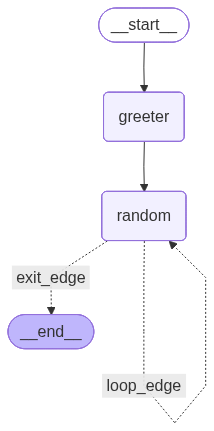

In [7]:
app

In [8]:
app.invoke({"name" : "Gaurang", "counter" : -2, "numbers" : []})

LOOPING  1
LOOPING  2
LOOPING  3
LOOPING  4


{'name': 'Hi, Gaurang. Welcome!', 'numbers': [18, 2, 14, 20, 7], 'counter': 5}